In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn.preprocessing as sp
import pickle
import matplotlib.pyplot as plt
import scipy
import os
import time
from datetime import date
from scipy.stats import ttest_ind
today = date.today()
import glob
import sqlite3

from utils import readSingleCellData_sqlalch, handle_nans, extract_cpfeature_names,\
    find_correlation, check_feature_similarity_dendrogram, find_end_slope2, plot_lollipop_feature_corr

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import seaborn as sns
print(sns.__version__)
import sklearn
print(sklearn.__version__)

0.13.2
1.8.0


In [31]:
def round_sig(x, sig=2):
#     To round to n significant digits (non-zero digits)
    if x == 0:
        return 0
    return round(x, sig - int(np.floor(np.log10(abs(x)))) - 1)

## Read Data

In [ ]:
compartments = ['mito','actin','dna']
# the directory data and images are stored in
dataDir="/Users/eweisbar/Desktop/github/2025_Haghighi_Mito/results/supplemental_single_cell_variability_cellsize/singleCellData/"
sql_data= "/Users/eweisbar/Desktop/profiles/"

df_1_0_0=pd.read_pickle(dataDir+'single_cell_with_annot.pkl', compression='infer')

sc_df_ls=[]
for fileName in glob.glob(f"{sql_data}/*.sqlite"):
    si = fileName.rsplit('/',1)[1].replace('.sqlite','')
    conn = sqlite3.connect(fileName)
    
    df_cells = pd.read_sql_query('SELECT * FROM Cells', conn)
    df_cyto = pd.read_sql_query('SELECT * FROM Cytoplasm', conn)
    df_nuc = pd.read_sql_query('SELECT * FROM Nuclei', conn)
    
    join_cols = ['ImageNumber', 'ObjectNumber']
    sc_df = pd.merge(df_cells, df_cyto, on=join_cols)
    sc_df = pd.merge(sc_df, df_nuc, on=join_cols)
    sc_df['subject']=si
    sc_df_ls.append(sc_df)

df_new = pd.concat(sc_df_ls,ignore_index=True)

TypeError: DataFrame cannot interpolate with object dtype.

In [ ]:

df_1_0=pd.read_pickle(dataDir+'single_cell_with_annot_allFeatures.pkl', compression='infer')
#df_1_0 = df_1_0.interpolate() #WHY IS THIS BEING DONE??

common_subjects = list(set(df_new['subject'].unique()) & set(df_1_0['subject'].unique()))
df_1 = df_new[df_new['subject'].isin(common_subjects)]


df_1 = pd.merge(df_1, df_1_0[['subject','label']].drop_duplicates(), on='subject',how='left')
disease_labels=pd.read_excel('/Users/eweisbar/Desktop/github/2025_Haghighi_Mito/metadata/patient_labels_updatedSept302025.xlsx')
disease_labels=disease_labels.rename(columns={"ID": "subject"})
disease_labels["subject"]=disease_labels["subject"].astype(str)

df_1 = pd.merge(df_1,disease_labels,on=["subject"],how="left")

df_1['subject'] = df_1['subject'].replace(['370E','370F','370H'],'370');

df_1.loc[df_1['subject']=='272','label']='Control'
df_1.loc[df_1['subject']=='MCL004','label']='SZA'

##################### Clean and shrink features
(
    cp_features,
    cp_features_analysis_0,
) = extract_cpfeature_names(df_1)
df_1, cp_features_analysis = handle_nans(
    df_1,
    cp_features_analysis_0,
    thrsh_null_ratio=0.05,
    thrsh_std=0.001,
    fill_na_method="drop-rows",
)
    

############### remove cells on the border
borderLength=200

im_width = 1388
im_height = 1040
print(df_1.shape)
df_1_centCells=df_1.loc[~((df_1['Nuclei_Location_Center_X']>(im_width-borderLength)) | (df_1['Nuclei_Location_Center_X']<(borderLength))\
                        | (df_1['Nuclei_Location_Center_Y']>(im_height-borderLength)) | (df_1['Nuclei_Location_Center_Y']<(borderLength))),:].reset_index(drop=True)

print("After border cell removal: ",df_1_centCells.shape)

df_1_centCells['Cells2Nuclei_MajorAxisLengthRatio']=df_1_centCells['Cells_AreaShape_MajorAxisLength']/df_1_centCells['Nuclei_AreaShape_MajorAxisLength']
df_1_centCells['Cells2Nuclei_AreaShapeRatio']=df_1_centCells['Cells_AreaShape_Area']/df_1_centCells['Nuclei_AreaShape_Area']
df_1_centCells = df_1_centCells[df_1_centCells['Cells2Nuclei_MajorAxisLengthRatio']>2].reset_index(drop=True)
df_1_centCells = df_1_centCells[df_1_centCells['Cells2Nuclei_AreaShapeRatio']>5].reset_index(drop=True)

print("After cell seg pron cells removal: ",df_1_centCells.shape)

df_1= df_1_centCells[(df_1_centCells['Cells_Intensity_MeanIntensity_Actin']<.5) &\
                                (df_1_centCells['Nuclei_Intensity_MeanIntensity_Actin']<.55)].reset_index(drop=True)

print("After intensity artifact cells removal: ",df_1.shape)


df_1, cp_features_analysis = handle_nans(
    df_1,
    cp_features_analysis,
    thrsh_null_ratio=0.05,
    thrsh_std=0.001,
    fill_na_method="drop-rows",
)


scaler = sp.StandardScaler()
s0=scaler.fit(df_1[cp_features_analysis])
df_1['label'] = df_1['label'].replace('MDD or Dep','MDD')
df_1_scaled=df_1.copy()

df_1_scaled[cp_features_analysis]=s0.transform(df_1[cp_features_analysis])


pat='CEN';ring='12';f_substr='MeanFrac';
target_columns=["Cells_RadialDistribution_"+f_substr+"_mito_tubeness_"+pat+"_"+str(i)+"of"+ring \
                            for i in range(int(ring)-11,int(ring)+1)]

df_1_avg_persub=df_1_scaled.groupby(["subject","label"])[cp_features_analysis].mean().reset_index()
ctrl=df_1_avg_persub[df_1_avg_persub['label']=='Control'][target_columns]

df_1_avg_persub[target_columns]=df_1_avg_persub[target_columns]-ctrl.mean()


df_1_avg_persub[["peak","slope"]] = df_1_avg_persub.apply(lambda x: find_end_slope2(x[target_columns]\
                                        ,plot=False,subject=x['subject'],smooth=True), axis=1,result_type='expand')
         
if 0:
    df_1_avg_persub.to_csv(dataDir+'/aggregated_profiles_fibroblast.csv',index=False)

cp_features: 2185


/Users/eweisbar/miniforge3/envs/marzieh_mito/lib/python3.14/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


cols2remove_manyNulls []
cols2remove_lowVars ['Nuclei_Texture_DifferenceVariance_DNA_3_01_256', 'Cytoplasm_Texture_DifferenceVariance_Actin_5_00_256', 'Cells_Texture_DifferenceVariance_Mito_5_01_256', 'Cells_Texture_DifferenceVariance_Actin_3_00_256', 'Cells_Texture_DifferenceVariance_Mito_5_02_256', 'Nuclei_Texture_DifferenceVariance_Actin_10_03_256', 'Nuclei_Texture_DifferenceVariance_DNA_3_03_256', 'Cytoplasm_Texture_DifferenceVariance_Mito_5_01_256', 'Nuclei_Texture_DifferenceVariance_Actin_5_00_256', 'Cytoplasm_Texture_DifferenceVariance_Actin_5_01_256', 'Nuclei_Texture_DifferenceVariance_Actin_3_03_256', 'Nuclei_Texture_DifferenceVariance_Actin_3_01_256', 'Nuclei_Texture_DifferenceVariance_DNA_10_03_256', 'Nuclei_Texture_DifferenceVariance_Mito_5_01_256', 'Nuclei_Texture_DifferenceVariance_Mito_5_00_256', 'Nuclei_Texture_DifferenceVariance_DNA_3_02_256', 'Cells_Texture_DifferenceVariance_Actin_5_03_256', 'Nuclei_Texture_DifferenceVariance_Actin_10_00_256', 'Cells_Texture_Differen

/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_59436/1786166674.py:79: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_1_avg_persub=df_1_scaled.groupby(["subject","label"])[cp_features_analysis].mean().reset_index()
/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_59436/1786166674.py:85: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_1_avg_persub[["peak","slope"]] = df_1_avg_persub.apply(lambda x: find_end_slope2(x[target_columns]\


In [47]:
# GROUP WITHOUT SCALING
df_1_avg_persub_unscaled=df_1.groupby(["subject","label"])[cp_features_analysis].mean().reset_index()
df_1_avg_persub_unscaled.to_csv(dataDir+'/aggregated_profiles_UNSCALED_fibroblast.csv',index=False)
data_phs_psych=df_1_avg_persub_unscaled[df_1_avg_persub_unscaled['label'].isin(["BP","SZ","SZA"])].copy()
data_phs_psych['label']='psychosis'
data_phs=pd.concat([df_1_avg_persub_unscaled,data_phs_psych],ignore_index=True)
#data_phs_collapsed=pd.merge(df_1_avg_persub_unscaled,disease_labels,on=["subject"],how="left")
#data_phs=pd.merge(df_1_avg_persub_unscaled,disease_labels,on=["subject"],how="left")

In [52]:
microns_per_pixel = .161

# convert features to microns
data_phs['Area_Microns'] = data_phs['Cells_AreaShape_Area'] * (microns_per_pixel ** 2)
data_phs['MajorAxisLength_Microns'] = data_phs['Cells_AreaShape_MajorAxisLength'] * microns_per_pixel
data_phs['MinorAxisLength_Microns'] = data_phs['Cells_AreaShape_MinorAxisLength'] * microns_per_pixel
data_phs['Perimeter_Microns'] = data_phs['Cells_AreaShape_Perimeter'] * microns_per_pixel

/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_59436/736356938.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_phs['Area_Microns'] = data_phs['Cells_AreaShape_Area'] * (microns_per_pixel ** 2)
/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_59436/736356938.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_phs['MajorAxisLength_Microns'] = data_phs['Cells_AreaShape_MajorAxisLength'] * microns_per_pixel
/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_59436/736356938.py:6: Performanc

/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_59436/826630537.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y=tar, data=data_phs,order=orderC,ax=axes,palette=palette,boxprops={'edgecolor':'none'})
/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_59436/826630537.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(labels);
/var/folders/zd/wz65pr5j3pz0sjgnjn4j4fn80000gp/T/ipykernel_59436/826630537.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y=tar, data=data_phs,order=orderC,ax=axes,palette=palette,boxprops={'edgecolor':'none'})
/v

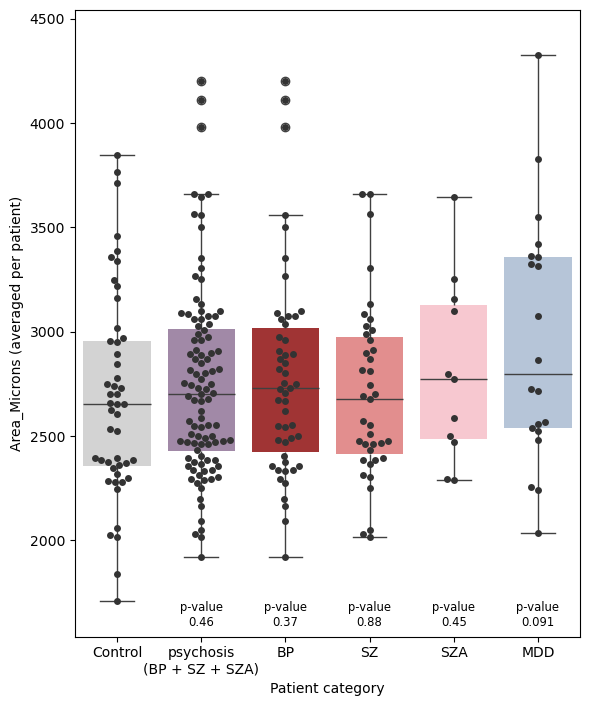

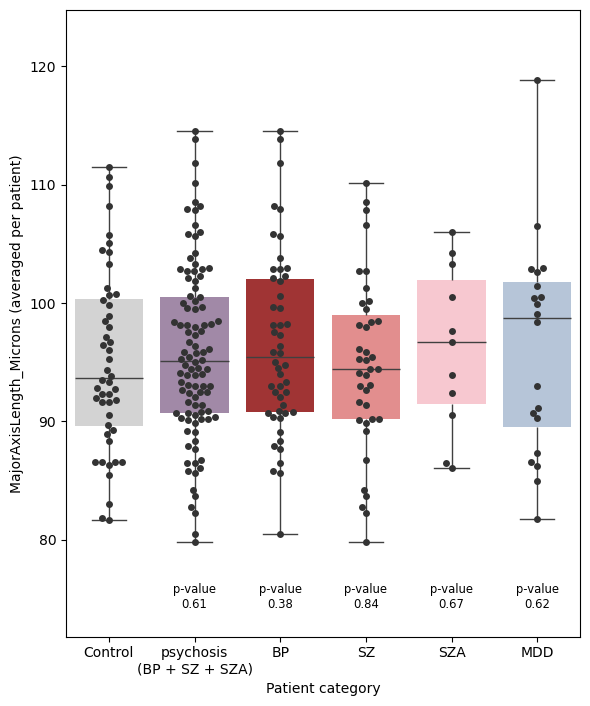

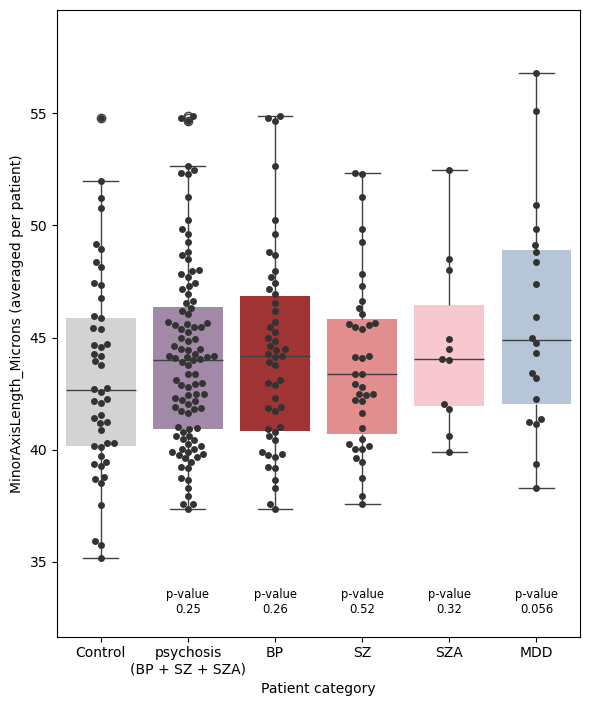

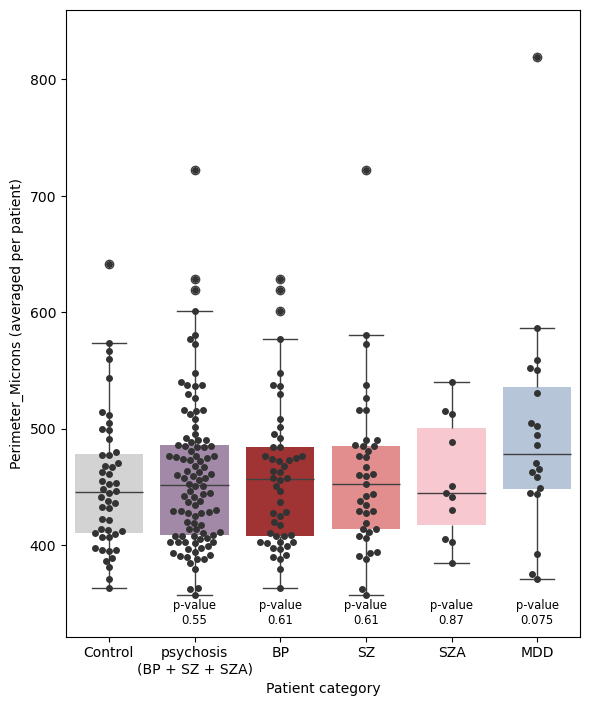

In [54]:
for tar in ['Area_Microns','MajorAxisLength_Microns','MinorAxisLength_Microns','Perimeter_Microns']:

    fig, axes = plt.subplots(1, 1, figsize=(6,7))
    # mediumvioletred
    orderC=["Control","psychosis","BP","SZ","SZA","MDD"]
    # palette = ['lightsteelblue','#a484ac','firebrick','lightcoral','pink','lightgreen']
    palette = ['lightgray','#a484ac','firebrick','lightcoral','pink','lightsteelblue']

    sns.boxplot(x="label", y=tar, data=data_phs,order=orderC,ax=axes,palette=palette,boxprops={'edgecolor':'none'})
    sns.swarmplot(x="label", y=tar, data=data_phs,order=orderC,ax=axes, color=".2")
    ############################
    mi,ma=data_phs[tar].describe()[['min','max']]
    # data_phs.loc[data_phs['label']=='Control',tar]

    for i in range(len(orderC)):
        if orderC[i]!='Control':
            pval=round_sig(ttest_ind(data_phs.loc[data_phs['label']=='Control',tar].values,\
                      data_phs.loc[data_phs['label']==orderC[i],tar].values,equal_var=False).pvalue,2)
            if pval<0.05:
                weight_f='bold';
            else:
                weight_f=None;
            axes.annotate('p-value\n'+str(pval),xy=(i,mi-(.07*mi)),horizontalalignment='center',size='small',weight=weight_f);

    axes.set_ylim([mi-(.1*mi),ma+(.05*ma)]);

    axes.set(ylabel=tar+' (averaged per patient)');

    axes.set(xlabel='Patient category');
    plt.tight_layout();

    labels = [tick.get_text() for tick in axes.get_xticklabels()];
    labels[1] = "psychosis\n(BP + SZ + SZA)"
    axes.set_xticklabels(labels);

In [60]:
# Example: all numeric columns except the target
y_col = "slope"
feature_cols = ['Area_Microns','MajorAxisLength_Microns','MinorAxisLength_Microns','Perimeter_Microns']

microns_per_pixel = .161

# convert features to microns
df_1_avg_persub_unscaled['Area_Microns'] = df_1_avg_persub_unscaled['Cells_AreaShape_Area'] * (microns_per_pixel ** 2)
df_1_avg_persub_unscaled['MajorAxisLength_Microns'] = df_1_avg_persub_unscaled['Cells_AreaShape_MajorAxisLength'] * microns_per_pixel
df_1_avg_persub_unscaled['MinorAxisLength_Microns'] = df_1_avg_persub_unscaled['Cells_AreaShape_MinorAxisLength'] * microns_per_pixel
df_1_avg_persub_unscaled['Perimeter_Microns'] = df_1_avg_persub_unscaled['Cells_AreaShape_Perimeter'] * microns_per_pixel

corrplot = df_1_avg_persub_unscaled.merge(df_1_avg_persub[['subject','label','slope']], on=['subject','label'], how='left')

# Compute correlation of each feature with target
corr = corrplot[feature_cols].corrwith(corrplot[y_col])
corr

Area_Microns               0.284611
MajorAxisLength_Microns    0.166055
MinorAxisLength_Microns    0.297302
Perimeter_Microns          0.393736
dtype: float64

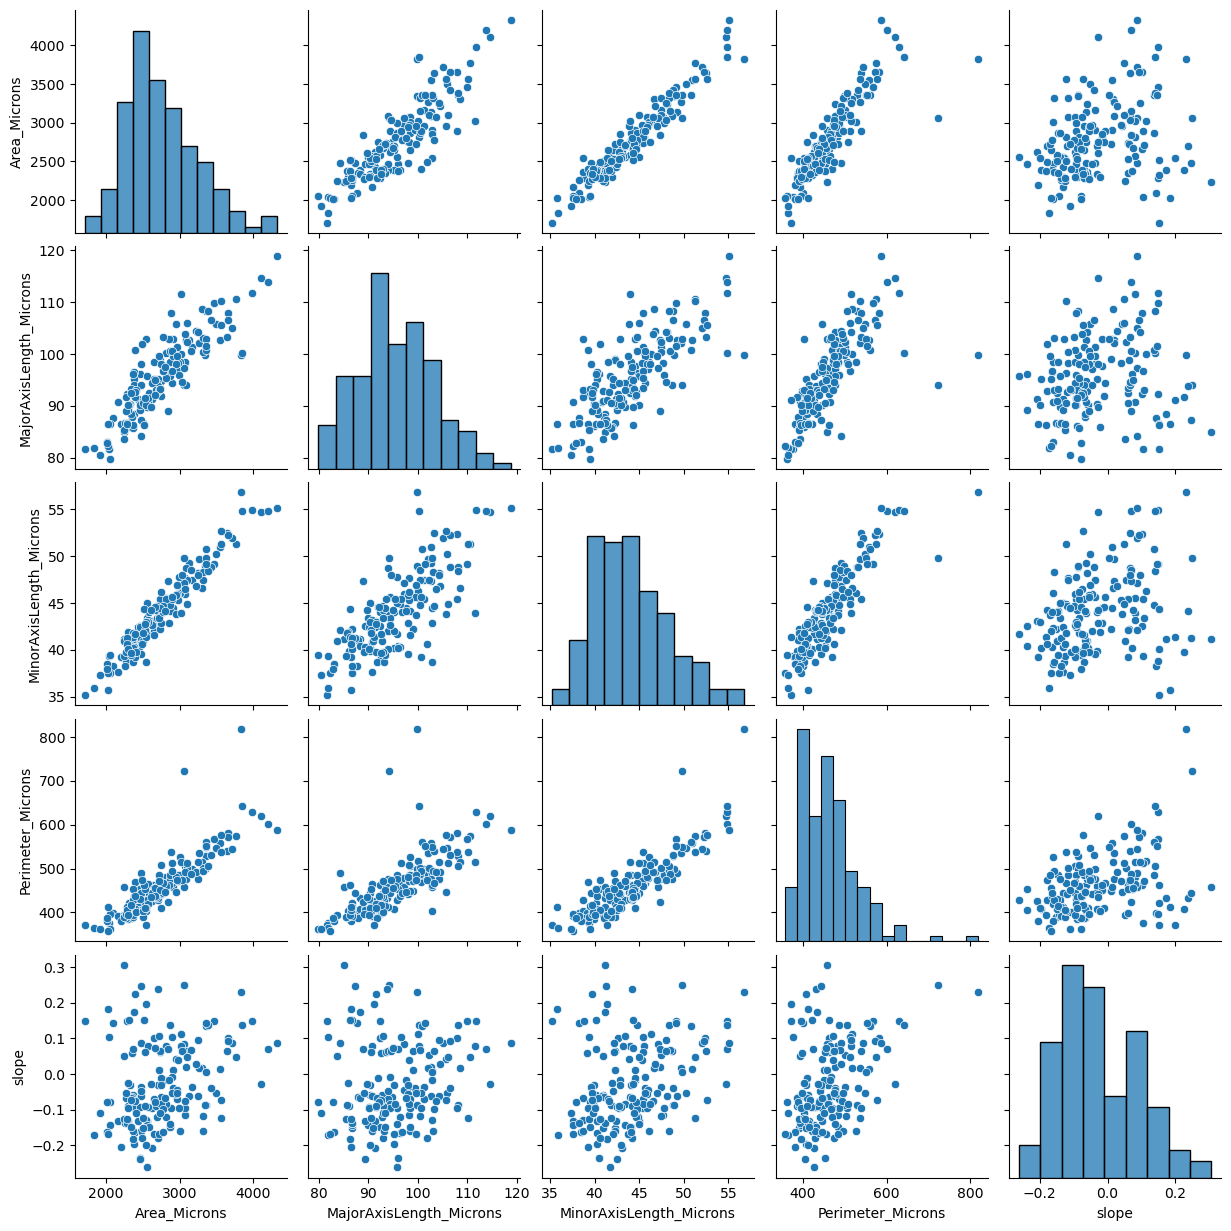

In [61]:
sns.pairplot(corrplot[feature_cols+['slope']])
plt.show()